In [1]:
import common_functions

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import numpy as np
import xarray as xr

In [2]:
dust_df = pd.read_csv("DATA/processed/3_dust_points_vars_2026-05-15.csv")
control_ds = xr.open_dataset("DATA/processed/4_control_grid_2026-05-15.nc")
control_ds_dust_sites = xr.open_dataset("DATA/processed/5_control_grid_dust_sites_2026-05-15.nc")

Create a side-by-side bar chart comparing:
- frequency of soil textures at dust points
- frequency of soil textures in the full soil raster

## Surface categories

In [3]:
soil_cmap, texture_colors, texture_dict = common_functions.get_texture_map_features()
land_cover_dict, land_cover_colors, classes = common_functions.get_land_cover_features()
soil_order_dict, category_colors = common_functions.get_soil_order_features()

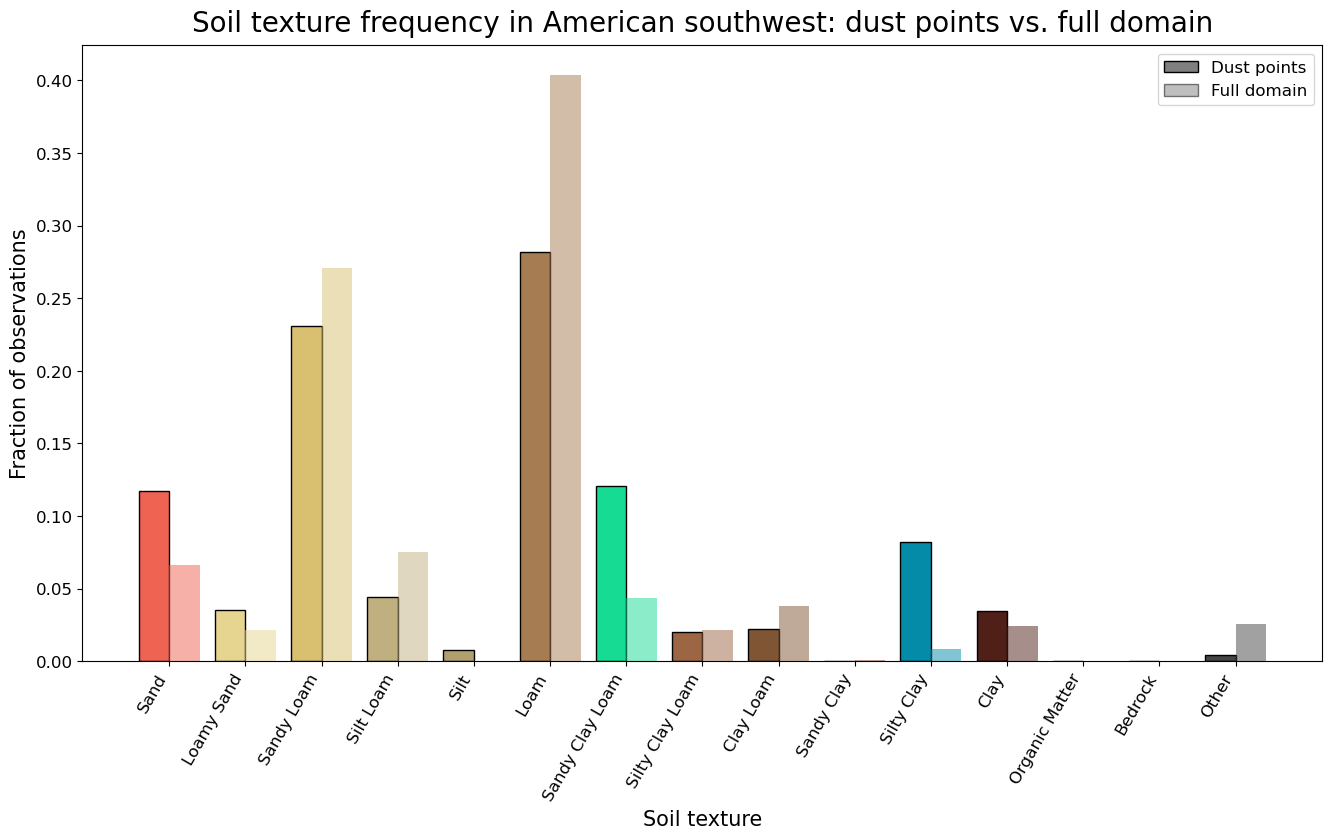

In [4]:
#--- Calculate bins
dust_counts = {k: np.sum(dust_df['texture'] == k) for k in texture_dict.keys()}
dust_total = sum(dust_counts.values())
dust_fraction = {k: v / dust_total for k, v in dust_counts.items()}

non_dust_counts = {k: np.sum(control_ds['soil_texture'] == k) for k in texture_dict.keys()}
non_dust_total = sum(non_dust_counts.values())
non_dust_fraction = {k: v / non_dust_total for k, v in non_dust_counts.items()}

categories = list(texture_dict.keys())
labels = [texture_dict[k] for k in categories]
x = np.arange(len(categories))
width = 0.4

fig, ax = plt.subplots(figsize=(16, 8))

for i, k in enumerate(categories):
    color = texture_colors[i]
    ax.bar(x[i] - width / 2, dust_fraction[k], width, color=color, edgecolor="black", label="Dust points" if i == 0 else "")
    ax.bar(x[i] + width / 2, non_dust_fraction[k], width, color=color, alpha=0.5, label="Full domain" if i == 0 else "")


ax.tick_params(labelsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=60, ha="right")
ax.set_ylabel("Fraction of observations", fontsize=15)
ax.set_xlabel("Soil texture", fontsize=15)
ax.set_title(f"Soil texture frequency in American southwest: dust points vs. full domain", fontsize=20, pad=10)

legend_elements = [
    Patch(facecolor="gray", edgecolor="black", label="Dust points"),
    Patch(facecolor="gray", edgecolor="black", alpha=0.5, label="Full domain")
]
ax.legend(handles=legend_elements, fontsize=12)

plt.savefig(f"plots/3_texture_1_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()

In [5]:
def add_medians_to_plot(ax_bar, median_dust, median_control):

    ax_bar.axvline(
        median_dust,
        color="tab:orange",
        linestyle="--",
        linewidth=2,
        zorder=0
    )
    ax_bar.text(x=median_dust, 
                y=0.84,
                s=f'Median: {median_dust:.2f}', 
                color="tab:orange",
                alpha=0.8, 
                fontsize=10,
                fontweight='bold',
                rotation=90,
                verticalalignment='center',
                horizontalalignment='right',
                transform=ax_bar.get_xaxis_transform())

    ax_bar.axvline(
        median_control,
        color="tab:blue",
        linestyle="--",
        linewidth=2,
        zorder=0
    )
    
    ax_bar.text(x=median_control, 
                y=0.84,
                s=f'Median: {median_control:.2f}', 
                color="tab:blue",
                alpha=0.8, 
                fontsize=10,
                fontweight='bold',
                rotation=90,
                verticalalignment='center',
                horizontalalignment='right',
                transform=ax_bar.get_xaxis_transform())
    
    return

## Continuous (wind and moisture)

Plotting wind speed bar chart...


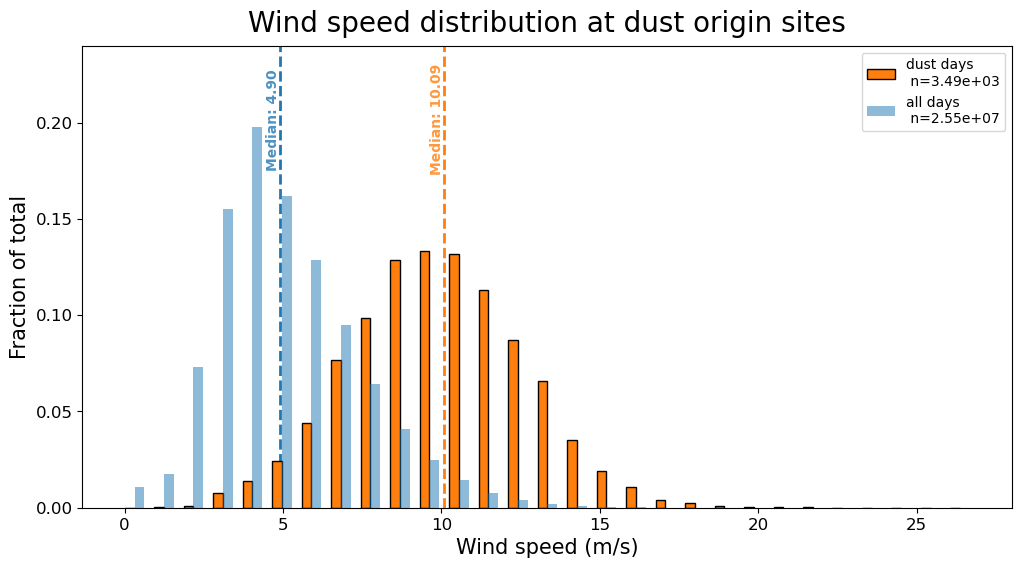

In [6]:
print("Plotting wind speed bar chart...")

#--- Calculate bins
bins = np.linspace(0, 27, 30)
counts_dust_days, _ = np.histogram(dust_df["wind_speed"], bins=bins)
counts_all_days, _ = np.histogram(control_ds_dust_sites["wind_speed"], bins=bins)
width = (bins[1] - bins[0]) / 3
density_dust_days = counts_dust_days / np.sum(counts_dust_days)
density_all_days = counts_all_days / np.sum(counts_all_days)

fig, ax_bar = plt.subplots(figsize=(12, 6))

plt.bar(bins[:-1], density_dust_days, 
        width=width, 
        align='edge', 
        color="tab:orange",
        edgecolor="black",
        linewidth=1,
        label=f"dust days \n n={len(dust_df["wind_speed"]) :.2e}",)
plt.bar(bins[:-1] + width, density_all_days, 
        width=width, 
        align='edge', 
        color="tab:blue",
        label=f"all days \n n={len(dust_df)*len(control_ds_dust_sites["wind_speed"]) :.2e}",
        alpha=0.5)

median_dust = dust_df["wind_speed"].median(skipna=True)
median_control = control_ds_dust_sites["wind_speed"].median(skipna=True)
add_medians_to_plot(ax_bar, median_dust, median_control)

ax_bar.tick_params(labelsize=12)
ax_bar.set_ylim(0,0.24)
ax_bar.set_ylabel("Fraction of total", fontsize=15)
ax_bar.set_xlabel("Wind speed (m/s)", fontsize=15)
ax_bar.set_title("Wind speed distribution at dust origin sites", fontsize=20, pad=10)

ax_bar.legend()
plt.savefig(f"plots/1_wind_speed_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()

Plotting moisture bar chart...


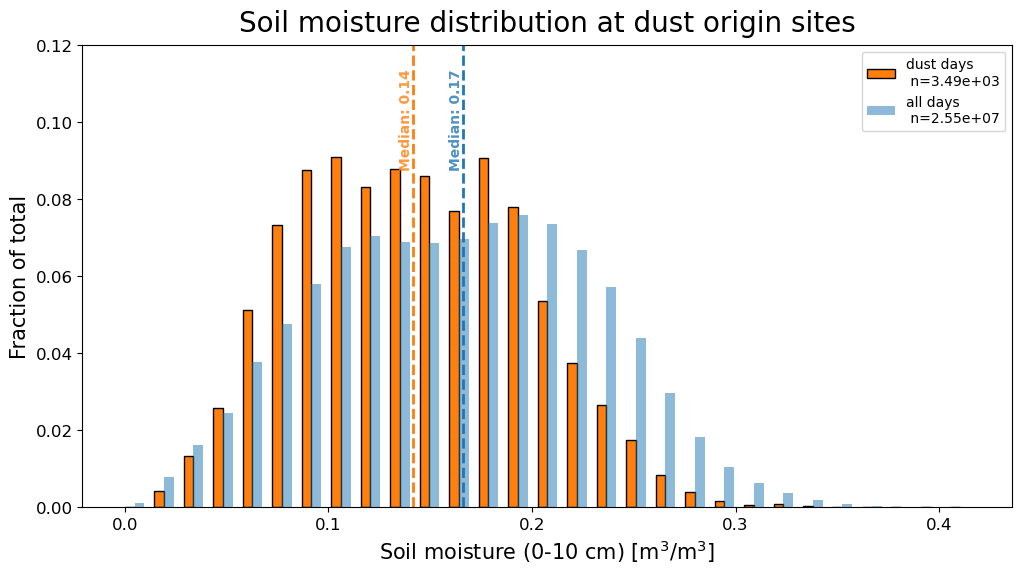

In [7]:
print("Plotting moisture bar chart...")

#--- Calculate bins
bins = np.linspace(0, 0.42, 30)
counts_dust_days, _ = np.histogram(dust_df["moisture"], bins=bins)
counts_all_days, _ = np.histogram(control_ds_dust_sites["SoilMoi00_10cm_tavg"], bins=bins)
width = (bins[1] - bins[0]) / 3
density_dust_days = counts_dust_days / np.sum(counts_dust_days)
density_all_days = counts_all_days / np.sum(counts_all_days)

fig, ax_bar = plt.subplots(figsize=(12, 6))

plt.bar(bins[:-1], density_dust_days, 
        width=width, 
        align='edge', 
        color="tab:orange",
        edgecolor="black",
        linewidth=1,
        label=f"dust days \n n={len(dust_df["moisture"]) :.2e}",)
plt.bar(bins[:-1] + width, density_all_days, 
        width=width, 
        align='edge', 
        color="tab:blue",
        label=f"all days \n n={len(dust_df)*len(control_ds["SoilMoi00_10cm_tavg"]) :.2e}",
        alpha=0.5)

median_dust = dust_df["moisture"].median(skipna=True)
median_control = control_ds_dust_sites["SoilMoi00_10cm_tavg"].median(skipna=True)
add_medians_to_plot(ax_bar, median_dust, median_control)

ax_bar.tick_params(labelsize=12)
ax_bar.set_ylim(0,0.12)
ax_bar.set_ylabel("Fraction of total", fontsize=15)
ax_bar.set_xlabel("Soil moisture (0-10 cm) [m$^3$/m$^3$]", fontsize=15)
ax_bar.set_title("Soil moisture distribution at dust origin sites", fontsize=20, pad=10)

ax_bar.legend()
plt.savefig(f"plots/2_soil_moisture_0_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()

## Combined surface categories

In [8]:
combo_three_ds = xr.open_dataset("DATA/processed/7_surface_combo_dust_2026-05-20.nc")

In [9]:
#--- Apply dictionaries to get the category names

land_cover_dict = common_functions.get_land_cover_dict()
soil_order_dict = common_functions.get_soil_order_dict()
texture_dict = common_functions.get_texture_dict()

combo_three_ds["combo_id"] = combo_three_ds["combo_id"].astype(int)

def decode_combo_id(combo_id):
    texture = combo_id // 1_000_000
    soil_order = (combo_id % 1_000_000) // 1_000
    surface_cover = combo_id % 1_000
    return texture, soil_order, surface_cover

def combo_id_to_label(combo_id):
    texture, soil, cover = decode_combo_id(combo_id)

    return (
        texture_dict.get(texture, f"Unknown({texture})"),
        soil_order_dict.get(soil, f"Unknown({soil})"),
        land_cover_dict.get(cover, f"Unknown({cover})")
    )

/home/jturner/miniconda3/envs/wldas_env/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:237: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


In [10]:
combo_three_df = combo_three_ds[["combo_id", "dust_event_count"]].to_dataframe().reset_index()

#--- Remove the null row
combo_three_df = combo_three_df[combo_three_df["combo_id"] != -9223372036854775808]

grouped = combo_three_df.groupby("combo_id").agg(
    dust_event_count=("dust_event_count", "sum"),
    full_domain=("combo_id", "size")
)
grouped = grouped.sort_values("dust_event_count", ascending=False)

decoded = [
    (cid, *combo_id_to_label(cid), row.dust_event_count, row.full_domain)
    for cid, row in grouped.iterrows()
]

top_df = pd.DataFrame(
    decoded,
    columns=["combo_id", "texture", "soil_order", "surface_cover", "dust_events", "full_domain"]
)

top_df["dust_fraction"] = (
    top_df["dust_events"] / top_df["dust_events"].sum()
)

top_df["full_domain_fraction"] = (
    top_df["full_domain"] / top_df["full_domain"].sum()
)

top_df

,combo_id,texture,soil_order,surface_cover,dust_events,full_domain,dust_fraction,full_domain_fraction
0,11101016,Silty Clay,Entisols,Barren Lands,171.0,70.0,0.049695,0.000379
1,6101007,Loam,Entisols,Tropical/Sub-tropical Shrubland,155.0,7546.0,0.045045,0.040808
2,7101007,Sandy Clay Loam,Entisols,Tropical/Sub-tropical Shrubland,142.0,2619.0,0.041267,0.014163
3,6050007,Loam,Aridisols,Tropical/Sub-tropical Shrubland,137.0,7437.0,0.039814,0.040219
4,6101009,Loam,Entisols,Tropical/Sub-tropical Grassland,134.0,1073.0,0.038942,0.005803
...,...,...,...,...,...,...,...,...
773,4255000,Silt Loam,Unknown(255),Unknown(0),0.0,47.0,0.000000,0.000254
774,4255001,Silt Loam,Unknown(255),Temp/Sub-polar Needleleaf Forest,0.0,1.0,0.000000,0.000005
775,4255017,Silt Loam,Unknown(255),Urban and Built-up,0.0,1.0,0.000000,0.000005
776,6000000,Loam,Water,Unknown(0),0.0,7.0,0.000000,0.000038


In [11]:
top_full = top_df.sort_values("full_domain_fraction", ascending=False)
top_full

,combo_id,texture,soil_order,surface_cover,dust_events,full_domain,dust_fraction,full_domain_fraction
6,3050008,Sandy Loam,Aridisols,Temp/Sub-polar Shrubland,106.0,11470.0,0.030805,0.062029
63,6070008,Loam,Mollisols,Temp/Sub-polar Shrubland,13.0,9627.0,0.003778,0.052062
21,6050008,Loam,Aridisols,Temp/Sub-polar Shrubland,43.0,9020.0,0.012496,0.048779
7,3050007,Sandy Loam,Aridisols,Tropical/Sub-tropical Shrubland,102.0,7560.0,0.029643,0.040884
1,6101007,Loam,Entisols,Tropical/Sub-tropical Shrubland,155.0,7546.0,0.045045,0.040808
...,...,...,...,...,...,...,...,...
700,4070003,Silt Loam,Mollisols,Tropical Broadleaf Evergreen Forest,0.0,1.0,0.000000,0.000005
750,6001010,Loam,Shifting Sands,Temp/Sub-polar Grassland,0.0,1.0,0.000000,0.000005
174,3001015,Sandy Loam,Shifting Sands,Cropland,1.0,1.0,0.000291,0.000005
775,4255017,Silt Loam,Unknown(255),Urban and Built-up,0.0,1.0,0.000000,0.000005


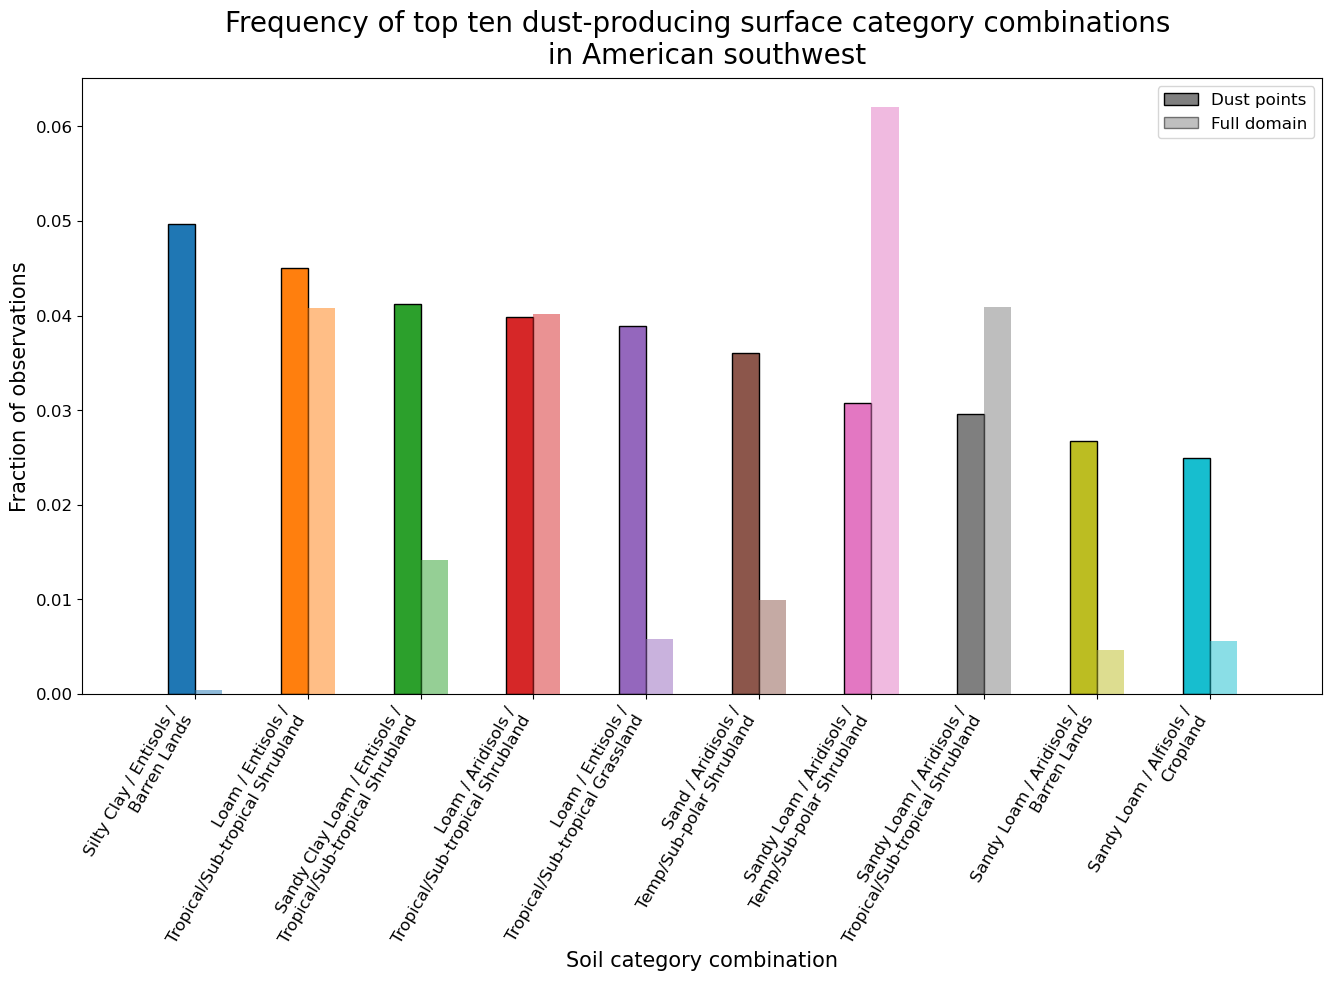

In [12]:
fig, ax = plt.subplots(figsize=(16, 8))

top_10_df = top_df[:10]
x = np.arange(len(top_10_df))
width = 0.24
x_labels = []

cmap = plt.cm.tab10
colors = cmap(np.linspace(0, 1, len(top_10_df)))

for i in np.arange(len(top_10_df)):
    ax.bar(
        x[i] - width/2,
        top_10_df['dust_fraction'][i],
        width=width,
        color=colors[i],
        edgecolor="black",
        label="Dust points" if i == 0 else None
    )
    ax.bar(
        x[i] + width/2,
        top_10_df['full_domain_fraction'][i],
        width=width,
        color=colors[i],
        alpha=0.5,
        edgecolor=None,
        label="Full domain" if i == 0 else None
    )
    x_labels.append(
        f"{top_10_df['texture'][i]} / "
        f"{top_10_df['soil_order'][i]} /\n"
        f"{top_10_df['surface_cover'][i]}"
    )

ax.set_xticks(x)
ax.tick_params(labelsize=12)
ax.set_xticklabels(x_labels, rotation=60, ha="right")
ax.set_ylabel("Fraction of observations", fontsize=15)
ax.set_xlim(-1, len(top_10_df))
ax.set_xlabel("Soil category combination", fontsize=15)
ax.set_title(f"Frequency of top ten dust-producing surface category combinations \n in American southwest", fontsize=20, pad=10)

legend_elements = [
    Patch(facecolor="gray", edgecolor="black", label="Dust points"),
    Patch(facecolor="gray", edgecolor="black", alpha=0.5, label="Full domain")
]
ax.legend(handles=legend_elements, fontsize=12)

plt.savefig(f"plots/6_combination_bar_chart.png",
            dpi=300, bbox_inches='tight')
plt.show()